1. Core-Shell Sphere

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sphere_amplitude(q, radius):
    """
    Dimensionless scattering amplitude for a uniform sphere.

    F(q, R) = 3 [sin(qR) - qR cos(qR)] / (qR)^3

    Handles qR = 0 safely.
    """
    q = np.asarray(q)
    x = q * radius

    F = np.ones_like(x, dtype=float)
    mask = x != 0
    F[mask] = 3 * (np.sin(x[mask]) - x[mask] * np.cos(x[mask])) / x[mask]**3

    return F

In [3]:
def sphere_form_factor(q, radius, scale=1.0, background=0.0):
    """
    Form factor intensity for a homogeneous solid sphere.
    """
    A = sphere_amplitude(q, radius)
    return scale * A**2 + background

In [6]:
def plot_form_factor(q, intensity, label=None):
    """
    Standard log-log plot for a form factor.
    """
    plt.figure(figsize=(7, 5))
    plt.loglog(q, intensity, label=label)

    if label is not None:
        plt.legend()

    plt.xlabel(r"$q$")
    plt.ylabel(r"$P(q)$")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

2. Shell-Model (Multilayer Sphere)


In [8]:
def multi_shell_amplitude(q, radii, slds, matrix_sld=0.0):
    """
    Scattering amplitude for a concentric multi-shell sphere.

    Parameters
    ----------
    q : array
        Scattering vector values.
    radii : list or array
        Outer radius of each concentric region.
        Example: [core_radius, shell_outer_radius]
    slds : list or array
        Scattering length density of each region.
        Must have same length as radii.
    matrix_sld : float
        Scattering length density of the surrounding solvent/matrix.

    Returns
    -------
    amplitude : array
        Total scattering amplitude.

    Notes
    -----
    The model is written as a sum over interfaces:

        A(q) = sum_i Δρ_i V_i F(q, R_i)

    where Δρ_i is the SLD jump at interface i.
    """
    q = np.asarray(q)
    radii = np.asarray(radii, dtype=float)
    slds = np.asarray(slds, dtype=float)

    if len(radii) != len(slds):
        raise ValueError("radii and slds must have the same length.")

    if np.any(np.diff(radii) <= 0):
        raise ValueError("radii must be strictly increasing.")

    amplitude = np.zeros_like(q, dtype=float)

    # Add matrix SLD as the final outside region
    extended_slds = np.append(slds, matrix_sld)

    for i, R in enumerate(radii):
        delta_rho = extended_slds[i] - extended_slds[i + 1]
        volume = (4 / 3) * np.pi * R**3
        amplitude += delta_rho * volume * sphere_amplitude(q, R)

    return amplitude

In [9]:
def multi_shell_form_factor(q, radii, slds, matrix_sld=0.0, scale=1.0, background=0.0):
    """
    Intensity from a concentric multi-shell sphere.
    """
    A = multi_shell_amplitude(q, radii, slds, matrix_sld)
    return scale * A**2 + background

Core-Shell Sphere

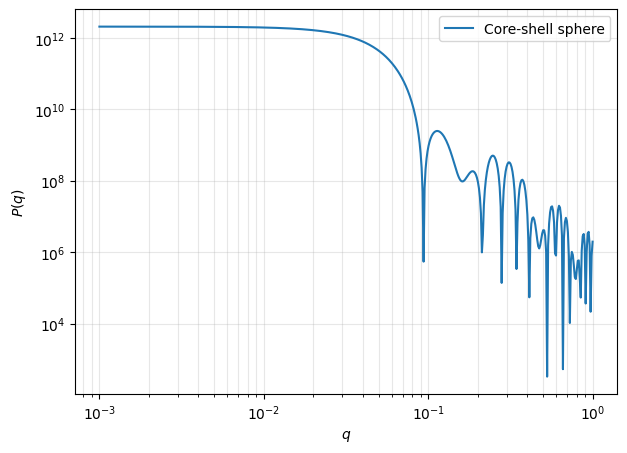

In [10]:
q = np.logspace(-3, 0, 500)

core_radius = 40
shell_outer_radius = 60

core_sld = 4.0
shell_sld = 2.0
matrix_sld = 1.0

I_core_shell = multi_shell_form_factor(
    q,
    radii=[core_radius, shell_outer_radius],
    slds=[core_sld, shell_sld],
    matrix_sld=matrix_sld
)

plot_form_factor(q, I_core_shell, label="Core-shell sphere")

Comparison between different shell contrasts: 

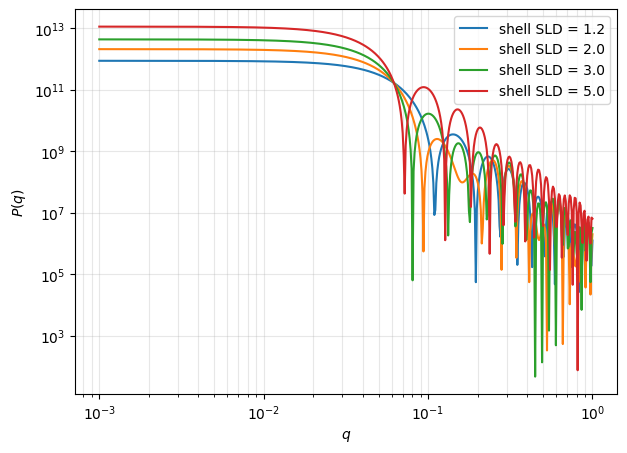

In [11]:
q = np.logspace(-3, 0, 500)

plt.figure(figsize=(7, 5))

for shell_sld in [1.2, 2.0, 3.0, 5.0]:
    I = multi_shell_form_factor(
        q,
        radii=[40, 60],
        slds=[4.0, shell_sld],
        matrix_sld=1.0
    )
    plt.loglog(q, I, label=f"shell SLD = {shell_sld}")

plt.xlabel(r"$q$")
plt.ylabel(r"$P(q)$")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

4. For multiple shells: 
    
    core | shell | outside solvent
    delta_rho = sld_inside - sld_outside

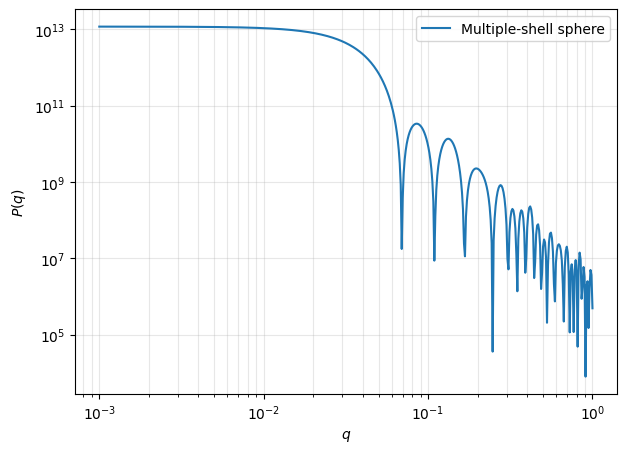

In [12]:
q = np.logspace(-3, 0, 500)

radii = [30, 45, 60, 75]
slds = [5.0, 3.0, 4.0, 2.0]
matrix_sld = 1.0

I_multi = multi_shell_form_factor(
    q,
    radii=radii,
    slds=slds,
    matrix_sld=matrix_sld
)

plot_form_factor(q, I_multi, label="Multiple-shell sphere")

Hollow sphere case 
    core and matrix have the same SLD
    aqueous interior "disappears" by contrast, and only the membrane shell scatters

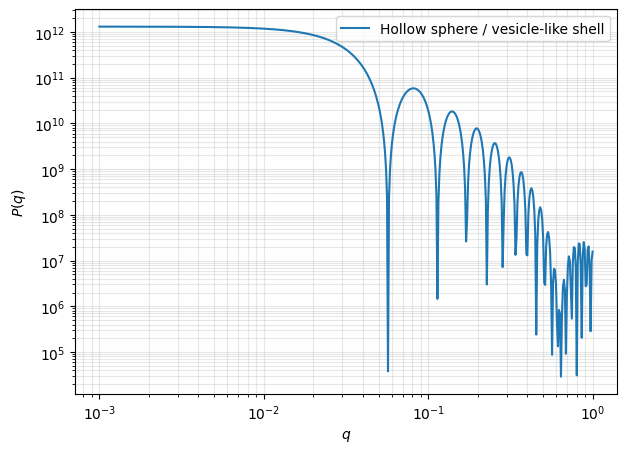

In [13]:
q = np.logspace(-3, 0, 500)

inner_radius = 50
outer_radius = 60

water_sld = 1.0
membrane_sld = 4.0
matrix_sld = 1.0

I_hollow = multi_shell_form_factor(
    q,
    radii=[inner_radius, outer_radius],
    slds=[water_sld, membrane_sld],
    matrix_sld=matrix_sld
)

plot_form_factor(q, I_hollow, label="Hollow sphere / vesicle-like shell")

Comparison between membrane thickness

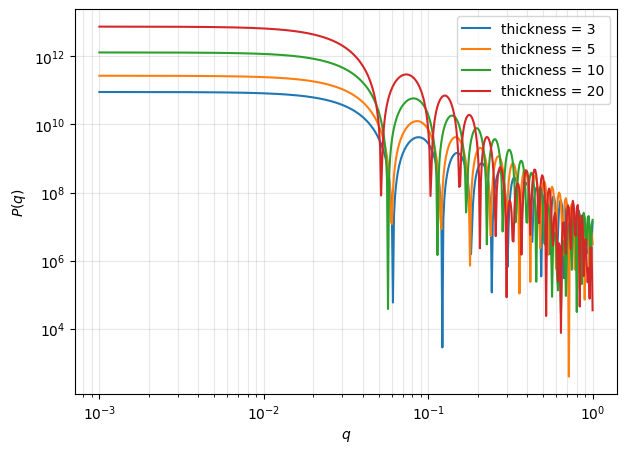

In [14]:
q = np.logspace(-3, 0, 500)

inner_radius = 50
water_sld = 1.0
membrane_sld = 4.0
matrix_sld = 1.0

plt.figure(figsize=(7, 5))

for thickness in [3, 5, 10, 20]:
    outer_radius = inner_radius + thickness

    I = multi_shell_form_factor(
        q,
        radii=[inner_radius, outer_radius],
        slds=[water_sld, membrane_sld],
        matrix_sld=matrix_sld
    )

    plt.loglog(q, I, label=f"thickness = {thickness}")

plt.xlabel(r"$q$")
plt.ylabel(r"$P(q)$")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Summary: 

Adding shells allows the model to describe particles whose scattering length density (SLD) changes with radius. Each shell introduces a new interface, and each interface contributes according to the difference in SLD across that boundary. When the SLD contrast is large, that interface contributes strongly to the scattering amplitude. When two adjacent regions have the same SLD, that boundary becomes invisible to scattering.

The hollow sphere is a special case of the core-shell model where the core and surrounding matrix have the same SLD. In that limit, the aqueous interior has no contrast with the solvent, so the measured scattering mainly comes from the membrane. This makes the hollow sphere model a useful first approximation for lipid vesicles.

General shell model uses different radii and SLD values to represent different sphere scenarios.



One General Tool:
multi_shell_form_factor()


Solid sphere:               one uniform material
Core-shell sphere:          dense core + outer shell
Multiple shells:            core + shell 1 + shell 2 + shell 3 ...
Hollow sphere/vesicle:      water inside + membrane + water outside



## Core-Shell Sphere 


In [22]:
import numpy as np

def sphere_amplitude(q, R):
    """
    Unsquared scattering amplitude F(q, R) for a uniform sphere.

    Parameters
    ----------
    q : array-like
        Scattering vector in Å^-1.
    R : float
        Sphere radius in Å.

    Returns
    -------
    numpy.ndarray
        Amplitude, normalized to F(q -> 0) = 1.
    """
    qR = q * R
    with np.errstate(invalid="ignore", divide="ignore"):
        F = np.where(
            qR < 1e-10,
            1.0,
            3.0 * (np.sin(qR) - qR * np.cos(qR)) / qR**3
        )
    return F


In [23]:
def core_shell_form_factor(q, R_core, t_shell, rho_core, rho_shell, rho_matrix):
    """
    Normalized form factor P(q) for a core-shell sphere.

    Parameters
    ----------
    q : array-like
        Scattering vector in Å^-1.
    R_core : float
        Core radius in Å.
    t_shell : float
        Shell thickness in Å.
    rho_core : float
        Core SLD in Å^-2.
    rho_shell : float
        Shell SLD in Å^-2.
    rho_matrix : float
        Matrix SLD in Å^-2.

    Returns
    -------
    numpy.ndarray
        P(q), normalized to 1 at q -> 0.
    """
    R_total = R_core + t_shell
    V_core  = (4/3) * np.pi * R_core**3
    V_total = (4/3) * np.pi * R_total**3

    # Sum amplitudes with contrast-weighted volumes
    F = ((rho_core  - rho_shell)  * V_core  * sphere_amplitude(q, R_core) +
         (rho_shell - rho_matrix) * V_total * sphere_amplitude(q, R_total))

    # Zero-q normalization (sphere_amplitude -> 1 as q -> 0)
    F0 = ((rho_core  - rho_shell)  * V_core +
          (rho_shell - rho_matrix) * V_total)

    return (F / F0)**2


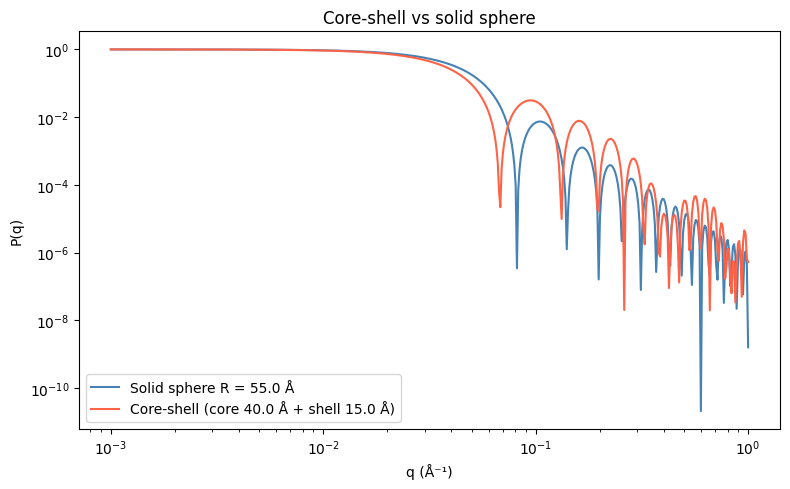

In [24]:
import matplotlib.pyplot as plt

q = np.logspace(-3, 0, 500)

# Baseline: solid sphere with same outer radius
R_core  = 40.0   # Å
t_shell = 15.0   # Å — shell thickness
R_total = R_core + t_shell

rho_core   = 10.0e-6   # Å^-2
rho_shell  = 14.0e-6   # Å^-2
rho_matrix =  9.47e-6  # water

P_sphere    = sphere_amplitude(q, R_total)**2
P_core_shell = core_shell_form_factor(q, R_core, t_shell,
                                       rho_core, rho_shell, rho_matrix)

def plot_form_factor(q, P, label=None, ax=None, color=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.loglog(q, P, label=label, color=color)
    ax.set_xlabel("q (Å⁻¹)")
    ax.set_ylabel("P(q)")
    ax.legend()
    return ax

fig, ax = plt.subplots(figsize=(8, 5))

plot_form_factor(
    q, P_sphere,
    label=f"Solid sphere R = {R_total} Å",
    ax=ax,
    color="steelblue"
)

plot_form_factor(
    q, P_core_shell,
    label=f"Core-shell (core {R_core} Å + shell {t_shell} Å)",
    ax=ax,
    color="tomato"
)

ax.set_title("Core-shell vs solid sphere")
plt.tight_layout()
plt.show()


Exercise 1: Set rho_shell = rho_core. What does the form factor look like? Does this make physical sense?

In [ ]:
def compare_core_shell(rho_shell_test, title):
    P_sphere = sphere_amplitude(q, R_total)**2

    P_core_shell = core_shell_form_factor(
        q, R_core, t_shell,
        rho_core, rho_shell_test, rho_matrix
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    plot_form_factor(
        q, P_sphere,
        label=f"Solid sphere R = {R_total} Å",
        ax=ax,
        color="steelblue"
    )

    plot_form_factor(
        q, P_core_shell,
        label=f"Core-shell, rho_shell = {rho_shell_test:.2e}",
        ax=ax,
        color="tomato"
    )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    

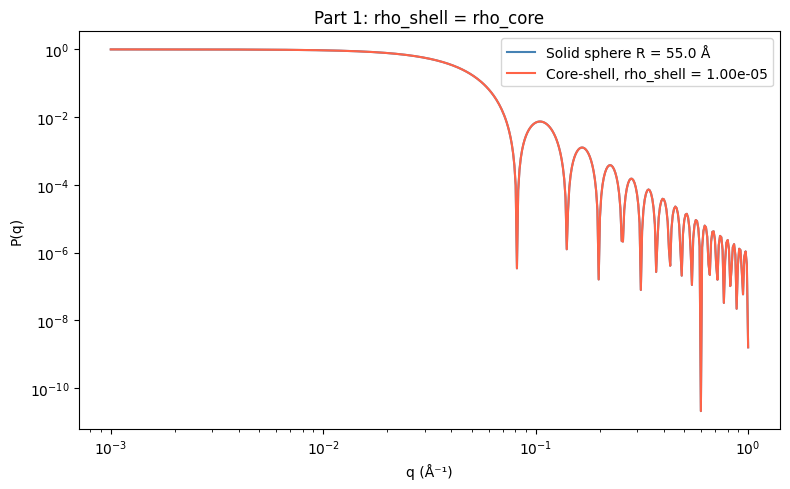

In [26]:
compare_core_shell(
    rho_shell_test=rho_core,
    title="Part 1: rho_shell = rho_core"
)

In [31]:
rho_shell_test = rho_core

P_sphere = sphere_amplitude(q, R_total)**2

P_core_shell = core_shell_form_factor(
    q, R_core, t_shell,
    rho_core, rho_shell_test, rho_matrix
)

np.max(np.abs(P_core_shell - P_sphere))

np.float64(2.220446049250313e-16)

The the red and blue curves perfectly overlap with each other, core and shell become one uniform material. 
The calculated result is very close to zero, like 1e-15 or smaller, then the two curves are mathematically the same up to tiny computer rounding error.



Exercise 2: Set rho_shell = rho_matrix. What does the form factor look like now? Which part of the particle is effectively invisible?

In [27]:
def compare_core_shell(rho_shell_test, title):
    P_sphere = sphere_amplitude(q, R_total)**2

    P_core_shell = core_shell_form_factor(
        q, R_core, t_shell,
        rho_core, rho_shell_test, rho_matrix
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    plot_form_factor(
        q, P_sphere,
        label=f"Solid sphere R = {R_total} Å",
        ax=ax,
        color="steelblue"
    )

    plot_form_factor(
        q, P_core_shell,
        label=f"Core-shell, rho_shell = {rho_shell_test:.2e}",
        ax=ax,
        color="tomato"
    )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

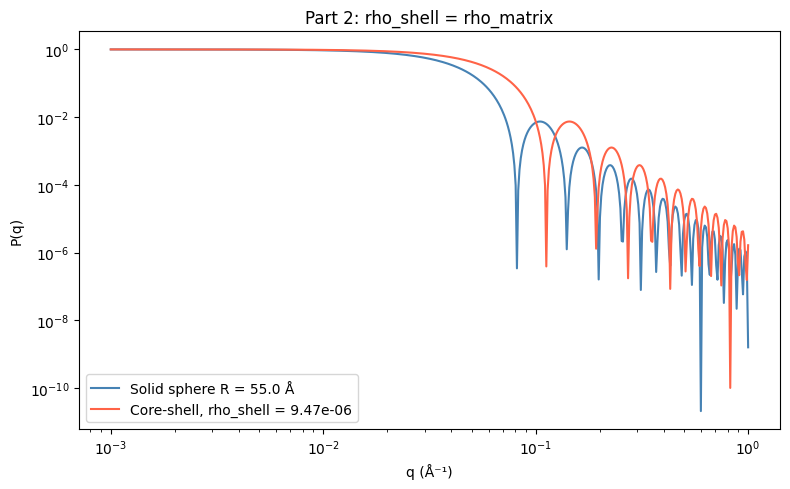

In [29]:
compare_core_shell(
    rho_shell_test=rho_matrix,
    title="Part 2: rho_shell = rho_matrix"
)

core-shell particle → behaves like core-only sphere

Particle behaves mostly like a solid core sphere, not like a full core-shell particle.  When the shell matches the matrix, the shell disappears in scattering. It is mainly measuring the core particle. 

Exercise 3: Set rho_shell to a value between rho_core and rho_matrix. How does the depth of the oscillations change compared to the extremes above?

In [28]:
def compare_core_shell(rho_shell_test, title):
    P_sphere = sphere_amplitude(q, R_total)**2

    P_core_shell = core_shell_form_factor(
        q, R_core, t_shell,
        rho_core, rho_shell_test, rho_matrix
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    plot_form_factor(
        q, P_sphere,
        label=f"Solid sphere R = {R_total} Å",
        ax=ax,
        color="steelblue"
    )

    plot_form_factor(
        q, P_core_shell,
        label=f"Core-shell, rho_shell = {rho_shell_test:.2e}",
        ax=ax,
        color="tomato"
    )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

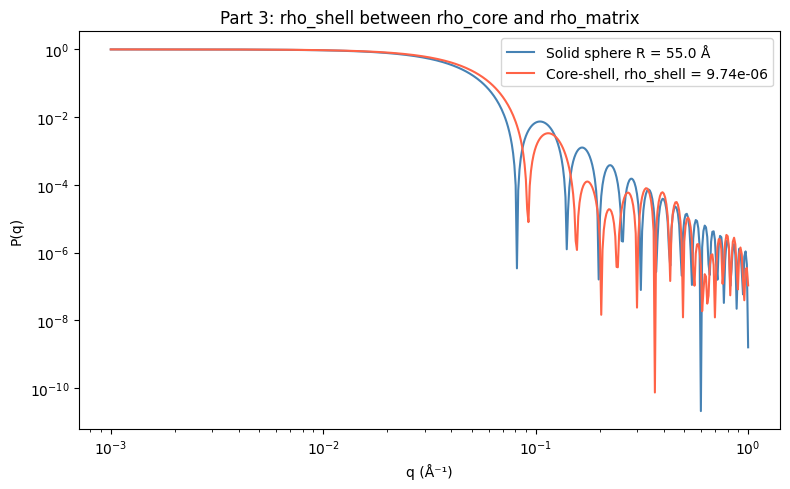

In [30]:
compare_core_shell(
    rho_shell_test=(rho_core + rho_matrix) / 2,
    title="Part 3: rho_shell between rho_core and rho_matrix"
)

The dips and peaks are interference features -> gives information about the size and internal structure of the particle.

A solid sphere has one main boundary, so its oscillations follow one clean size scale.
A core-shell sphere has two boundaries, so the curve becomes more complicated. The locations and depths of the dips tell you whether the particle behaves more like:
    a solid sphere,
    an invisible-shell particle,
    or a true core-shell particle.


## Multiple Shells 



In [ ]:
def multi_shell_form_factor(q, radii, slds, rho_matrix):
    """
    Normalized form factor P(q) for a multi-shell sphere.

    Parameters
    ----------
    q : array-like
        Scattering vector in Å^-1.
    radii : list of float
        Outer radius of each shell from innermost to outermost, in Å.
        radii[0] is the core radius; radii[-1] is the total particle radius.
    slds : list of float
        SLD of each shell from innermost to outermost, in Å^-2.
        Must be the same length as radii.
    rho_matrix : float
        SLD of the surrounding medium in Å^-2.

    Returns
    -------
    numpy.ndarray
        P(q), normalized to 1 at q -> 0.
    """
    # Append the matrix as the region beyond the outermost shell
    slds_ext = list(slds) + [rho_matrix]  # (1)

    F  = np.zeros_like(q, dtype=float)
    F0 = 0.0

    for i, R in enumerate(radii):
        V          = (4/3) * np.pi * R**3
        delta_rho  = slds_ext[i] - slds_ext[i + 1]  # (2)
        F  += delta_rho * V * sphere_amplitude(q, R)
        F0 += delta_rho * V                           # F at q=0

    return (F / F0)**2


## Connection to Vesicles 
